# HBB: whole vs. sum of parts (AlphaGenome, GTEx whole blood)

## Imports

In [1]:
import dataclasses
import os

import duckdb
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from alphagenome.data import gene_annotation
from alphagenome.data import genome
from alphagenome.data import transcript as transcript_utils
from alphagenome.visualization import plot_transcripts

from figutils import cm, set_figure_style

set_figure_style()

PDF_DIR = "pdfs/hbb"
os.makedirs(PDF_DIR, exist_ok=True)

TRACK_NAME = "UBERON:0013756 gtex Whole_Blood polyA plus RNA-seq"
TRACK_STRAND = "."
HBB_GENE_ID = "ENSG00000244734"
CHROMOSOME = "chr11"

## Data

In [2]:
SCALE = "full"
ROOT = ".."
WHOLE_VS_SUM_PARTS = f"{ROOT}/results/03-analysis/hbb_wholeblood/whole_vs_sum_parts.{SCALE}.parquet"
UNIQUE_VARIANT_SCORES = f"{ROOT}/results/03-analysis/hbb_wholeblood/unique_variant_scores.{SCALE}.parquet"
GTF_PARQUET = f"{ROOT}/data/raw/GENCODE/release_46/gencode.v46.annotation.gtf.parquet"

WINDOW = {"dev": (5221202, 5237586), "full": (4705106, 5753682)}[SCALE]
INTERVAL = genome.Interval(CHROMOSOME, *WINDOW)

con = duckdb.connect()
combined = con.execute(
    "SELECT * FROM read_parquet(?) WHERE track_name = ? AND track_strand = ?",
    [WHOLE_VS_SUM_PARTS, TRACK_NAME, TRACK_STRAND],
).df()

singles = con.execute(
    "SELECT * FROM read_parquet(?) WHERE track_name = ? AND track_strand = ?",
    [UNIQUE_VARIANT_SCORES, TRACK_NAME, TRACK_STRAND],
).df()
score_by_variant = singles.set_index("variant")["score"]

len(combined)

1842

## Gene annotation

In [3]:
gtf = pd.read_parquet(GTF_PARQUET)
gtf_coding = gene_annotation.filter_protein_coding(gtf)
gtf_coding = gene_annotation.filter_to_longest_transcript(gtf_coding)
transcript_extractor = transcript_utils.TranscriptExtractor(gtf_coding)

transcripts_overview = transcript_extractor.extract(INTERVAL)
hbb_transcript = next(
    t for t in transcripts_overview if t.gene_id is not None and t.gene_id.split(".")[0] == HBB_GENE_ID
)
hbb_start, hbb_end = hbb_transcript.transcript_interval.start, hbb_transcript.transcript_interval.end

ZOOM_PAD = 5000
ZOOM_INTERVAL = genome.Interval(CHROMOSOME, hbb_start - ZOOM_PAD, hbb_end + ZOOM_PAD)
transcripts_zoom = transcript_extractor.extract(ZOOM_INTERVAL)

len(transcripts_overview), len(transcripts_zoom)

/users/diasfrazer/manglada/projects/wigttsoip/src/alphagenome/src/alphagenome/data/transcript.py:661: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for chromosome, dfc in df.groupby('Chromosome')


(42, 2)

## Genomic annotation: 1Mb overview and HBB zoom

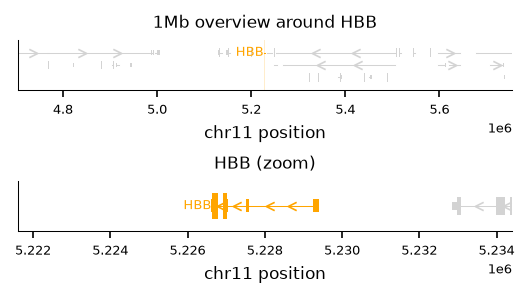

In [4]:
GRAY_STYLE = dataclasses.replace(
    plot_transcripts.TranscriptStylePreset.STANDARD.value,
    cds_color="lightgray", utr5_color="lightgray", utr3_color="lightgray",
    first_noncoding_exon_color="lightgray", label_color="gray",
)
ORANGE_STYLE = dataclasses.replace(
    plot_transcripts.TranscriptStylePreset.STANDARD.value,
    cds_color="orange", utr5_color="orange", utr3_color="orange",
    first_noncoding_exon_color="orange", label_color="orange",
)


def draw_gene_track(ax, transcripts, interval, cds_scale=1.0):
    hbb = [t for t in transcripts if t.gene_id is not None and t.gene_id.split(".")[0] == HBB_GENE_ID]
    others = [t for t in transcripts if t not in hbb]
    heights = plot_transcripts._get_placement_heights(transcripts, extend_fraction=1.0)
    for t in others:
        plot_transcripts.draw_transcript(
            ax=ax, transcript=t, interval=interval, y=heights[t.transcript_id],
            cds_height=GRAY_STYLE.cds_height, utr_height=GRAY_STYLE.utr_height,
            cds_color=GRAY_STYLE.cds_color, utr5_color=GRAY_STYLE.utr5_color,
            utr3_color=GRAY_STYLE.utr3_color,
            first_noncoding_exon_color=GRAY_STYLE.first_noncoding_exon_color,
            label_color=GRAY_STYLE.label_color, label=None, zorder=1,
        )
    for t in hbb:
        plot_transcripts.draw_transcript(
            ax=ax, transcript=t, interval=interval, y=heights[t.transcript_id],
            cds_height=ORANGE_STYLE.cds_height * cds_scale, utr_height=ORANGE_STYLE.utr_height * cds_scale,
            cds_color=ORANGE_STYLE.cds_color, utr5_color=ORANGE_STYLE.utr5_color,
            utr3_color=ORANGE_STYLE.utr3_color,
            first_noncoding_exon_color=ORANGE_STYLE.first_noncoding_exon_color,
            label_color=ORANGE_STYLE.label_color, label="HBB", zorder=2,
        )
    ax.set_xlim(interval.start, interval.end)
    ax.set_ylim(min(heights.values()) - 1, max(heights.values()) + 1)
    ax.set_yticks([])
    ax.set_xlabel(f"{CHROMOSOME} position")


fig, (ax_overview, ax_zoom) = plt.subplots(2, 1, figsize=(9*cm, 5*cm))

draw_gene_track(ax_overview, transcripts_overview, INTERVAL, cds_scale=1.0)
ax_overview.axvspan(hbb_start, hbb_end, color="orange", alpha=0.2, zorder=0, lw=0)
ax_overview.set_title("1Mb overview around HBB")

draw_gene_track(ax_zoom, transcripts_zoom, ZOOM_INTERVAL, cds_scale=1.5)
ax_zoom.set_title("HBB (zoom)")

fig.tight_layout()
fig.savefig(os.path.join(PDF_DIR, "gene_annotation.pdf"), bbox_inches="tight")

## Variant burden per individual

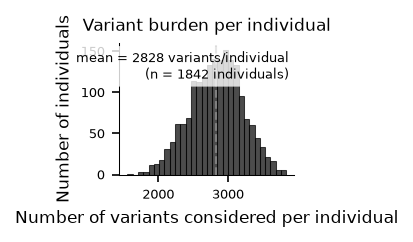

In [5]:
fig, ax = plt.subplots(figsize=(4.5*cm, 4*cm))
ax.hist(combined["n_variants_matched"], bins=30, color="black", alpha=0.7)
mean_n = combined["n_variants_matched"].mean()
ax.axvline(mean_n, color="gray", lw=1, ls="--")
ax.text(
    0.97, 0.95, f"mean = {mean_n:.0f} variants/individual\n(n = {len(combined)} individuals)",
    transform=ax.transAxes, ha="right", va="top",
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="none", alpha=0.8),
)
ax.set_xlabel("Number of variants considered per individual")
ax.set_ylabel("Number of individuals")
ax.set_title("Variant burden per individual")
fig.tight_layout()
fig.savefig(os.path.join(PDF_DIR, "variant_burden.pdf"), bbox_inches="tight")

## Effect distributions: combinatorial vs. summed individual

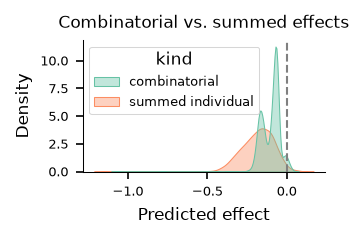

In [6]:
effects_long = pd.concat([
    combined[["whole_score"]].rename(columns={"whole_score": "effect"}).assign(kind="combinatorial"),
    combined[["sum_parts_score"]].rename(columns={"sum_parts_score": "effect"}).assign(kind="summed individual"),
])

fig, ax = plt.subplots(figsize=(5.5*cm, 4*cm))
sns.kdeplot(
    data=effects_long, x="effect", hue="kind",
    fill=True, common_norm=False, alpha=0.4, palette="Set2", ax=ax,
)
ax.axvline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("Predicted effect")
ax.set_title("Combinatorial vs. summed effects")
fig.tight_layout()
fig.savefig(os.path.join(PDF_DIR, "effect_distributions.pdf"), bbox_inches="tight")

## Combined vs. sum of independent effects

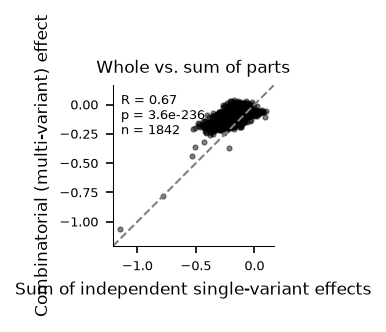

In [7]:
x = combined["sum_parts_score"].to_numpy()
y = combined["whole_score"].to_numpy()
r, p = stats.pearsonr(x, y)
rho, p_rho = stats.spearmanr(x, y)
n = len(combined)

fig, ax = plt.subplots(figsize=(4.5*cm, 4.5*cm))
ax.scatter(x, y, s=6, color="black", alpha=0.5, rasterized=True)

lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
pad = 0.05 * (hi - lo) if hi > lo else 1.0
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], ls="--", color="gray", lw=1)
ax.set_xlim(lo - pad, hi + pad)
ax.set_ylim(lo - pad, hi + pad)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("Sum of independent single-variant effects")
ax.set_ylabel("Combinatorial (multi-variant) effect")
ax.set_title("Whole vs. sum of parts")
ax.text(
    0.05, 0.95, f"R = {r:.2f}\np = {p:.1e}\nn = {n}",
    transform=ax.transAxes, ha="left", va="top",
)
fig.tight_layout()
fig.savefig(os.path.join(PDF_DIR, "whole_vs_sum.pdf"), bbox_inches="tight")

## Per-sample variant scores

In [8]:
def _variant_scores(variant_id):
    if not variant_id:
        return np.array([])
    scores = []
    for v in variant_id.split(";"):
        chrom, pos, ref_alt = v.split(":")
        variant = f"{chrom}:{int(pos) + 1}:{ref_alt}"
        s = score_by_variant.get(variant, np.nan)
        if np.isfinite(s):
            scores.append(s)
    return np.array(scores)

combined["scores"] = combined["variant_id"].apply(_variant_scores)

## Effective dimensionality: correlation vs. number of top variants

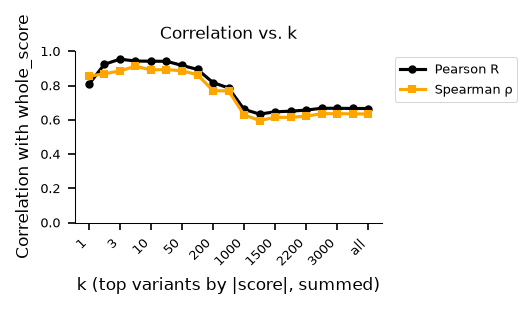

In [9]:
K_VALUES = [1, 2, 3, 5, 10, 20, 50, 100, 200, 500, 1000, 1200, 1500, 2000, 2200, 2500, 3000, 3200]

def _topk_sum(scores, k):
    if len(scores) == 0:
        return np.nan
    order = np.argsort(-np.abs(scores))
    return scores[order][:k].sum()


combined["sum_top3_score"] = combined["scores"].apply(lambda s: _topk_sum(s, 3))

ks = K_VALUES + ["all"]
y = combined["whole_score"].to_numpy()
pearsons, spearmans = [], []
for k in ks:
    if k == "all":
        x = combined["sum_parts_score"].to_numpy()
    else:
        x = combined["scores"].apply(lambda s: _topk_sum(s, k)).to_numpy()
    mask = np.isfinite(x) & np.isfinite(y)
    r, _ = stats.pearsonr(x[mask], y[mask])
    rho, _ = stats.spearmanr(x[mask], y[mask])
    pearsons.append(r)
    spearmans.append(rho)

fig, ax = plt.subplots(figsize=(9*cm, 5*cm))
ax.plot(range(len(ks)), pearsons, marker="o", markersize=3, color="black", label="Pearson R")
ax.plot(range(len(ks)), spearmans, marker="s", markersize=3, color="orange", label="Spearman ρ")
ax.set_xticks(range(len(ks))[::2])
ax.set_xticklabels([str(k) for k in ks][::2], rotation=45, ha="right")
ax.set_ylim(0, 1)
ax.set_xlabel("k (top variants by |score|, summed)")
ax.set_ylabel("Correlation with whole_score")
ax.set_title("Correlation vs. k")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
fig.tight_layout()
fig.savefig(os.path.join(PDF_DIR, "correlation_vs_k.pdf"), bbox_inches="tight")

## Effect distributions: combinatorial vs. summed top 3

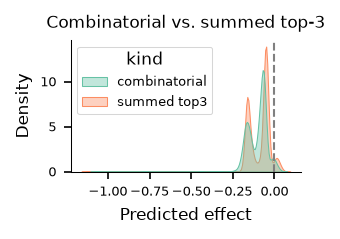

In [10]:
effects_long = pd.concat([
    combined[["whole_score"]].rename(columns={"whole_score": "effect"}).assign(kind="combinatorial"),
    combined[["sum_top3_score"]].rename(columns={"sum_top3_score": "effect"}).assign(kind="summed top3"),
])

fig, ax = plt.subplots(figsize=(5.5*cm, 4*cm))
sns.kdeplot(
    data=effects_long, x="effect", hue="kind",
    fill=True, common_norm=False, alpha=0.4, palette="Set2", ax=ax,
)
ax.axvline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("Predicted effect")
ax.set_title("Combinatorial vs. summed top-3")
fig.tight_layout()
fig.savefig(os.path.join(PDF_DIR, "effect_distributions_top3.pdf"), bbox_inches="tight")

## Combined vs. sum of top 3 independent effects

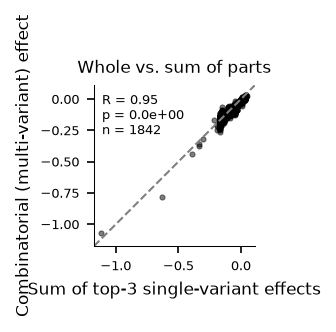

In [11]:
x = combined["sum_top3_score"].to_numpy()
y = combined["whole_score"].to_numpy()
r, p = stats.pearsonr(x, y)
rho, p_rho = stats.spearmanr(x, y)
n = len(combined)

fig, ax = plt.subplots(figsize=(4.5*cm, 4.5*cm))
ax.scatter(x, y, s=6, color="black", alpha=0.5, rasterized=True)

lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
pad = 0.05 * (hi - lo) if hi > lo else 1.0
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], ls="--", color="gray", lw=1)
ax.set_xlim(lo - pad, hi + pad)
ax.set_ylim(lo - pad, hi + pad)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("Sum of top-3 single-variant effects")
ax.set_ylabel("Combinatorial (multi-variant) effect")
ax.set_title("Whole vs. sum of parts")
ax.text(
    0.05, 0.95, f"R = {r:.2f}\np = {p:.1e}\nn = {n}",
    transform=ax.transAxes, ha="left", va="top",
)
fig.tight_layout()
fig.savefig(os.path.join(PDF_DIR, "whole_vs_sum_top3.pdf"), bbox_inches="tight")

## Correlation vs. k, across every gene in the window

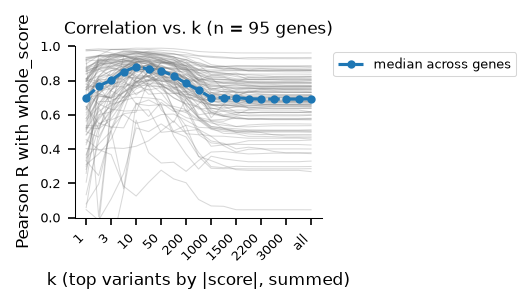

In [12]:
GENE_TOPK_PATH = f"{ROOT}/results/03-analysis/hbb_wholeblood/topk_correlation_per_gene.full.parquet"
gene_topk = pd.read_parquet(GENE_TOPK_PATH)

ks_order = [str(k) for k in K_VALUES] + ["all"]
pivot = gene_topk.pivot(index="gene_id", columns="k", values="pearson_r")[ks_order]
n_genes = pivot.shape[0]

fig, ax = plt.subplots(figsize=(9*cm, 5*cm))
x = range(len(ks_order))
for _, row in pivot.iterrows():
    ax.plot(x, row.to_numpy(), color="gray", alpha=0.3, lw=0.5)
median_r = pivot.median(axis=0)
ax.plot(x, median_r.to_numpy(), color="tab:blue", ls="--", lw=1.5, marker="o", markersize=3, label="median across genes")
ax.set_xticks(list(x)[::2])
ax.set_xticklabels(ks_order[::2], rotation=45, ha="right")
ax.set_ylim(0, 1)
ax.set_xlabel("k (top variants by |score|, summed)")
ax.set_ylabel("Pearson R with whole_score")
ax.set_title(f"Correlation vs. k (n = {n_genes} genes)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
fig.tight_layout()
fig.savefig(os.path.join(PDF_DIR, "correlation_vs_k_all_genes.pdf"), bbox_inches="tight")

## Correlation vs. k, faceted by gene's baseline (reference) expression

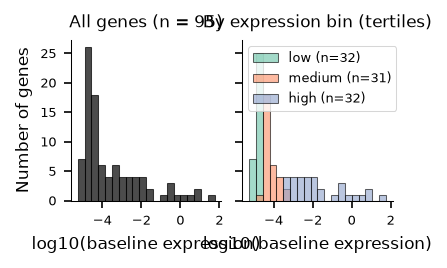

In [13]:
REF_GENE_EXPRESSION_PATH = f"{ROOT}/results/02-preprocess_data/alphagenome/hbb_window/ref_gene_expression.full.parquet"
ref_expr = pd.read_parquet(REF_GENE_EXPRESSION_PATH)
ref_expr = ref_expr[(ref_expr["track_name"] == TRACK_NAME) & (ref_expr["track_strand"] == TRACK_STRAND)]
ref_expr_by_gene = ref_expr.set_index("gene_id")["ref_expression"]

# Quantile (not equal-width) tertiles: baseline expression spans ~6 orders of magnitude and
# is heavily right-skewed (a handful of highly-expressed genes, HBB itself the extreme
# outlier), so equal-width bins on the raw value would dump nearly every gene into "low".
EXPR_BIN_LABELS = ["low", "medium", "high"]
EXPR_BIN_COLORS = dict(zip(EXPR_BIN_LABELS, sns.color_palette("Set2", 3)))
expr_bin_by_gene = pd.qcut(ref_expr_by_gene, q=3, labels=EXPR_BIN_LABELS)

log_expr = np.log10(ref_expr_by_gene)
bin_edges = np.linspace(log_expr.min(), log_expr.max(), 21)

fig, (ax_all, ax_hue) = plt.subplots(1, 2, figsize=(7*cm, 4.5*cm), sharex=True, sharey=True)

ax_all.hist(log_expr, bins=bin_edges, color="black", alpha=0.7)
ax_all.set_title(f"All genes (n = {len(log_expr)})")
ax_all.set_xlabel("log10(baseline expression)")
ax_all.set_ylabel("Number of genes")

for label in EXPR_BIN_LABELS:
    vals = log_expr[expr_bin_by_gene == label]
    ax_hue.hist(vals, bins=bin_edges, color=EXPR_BIN_COLORS[label], alpha=0.6, label=f"{label} (n={len(vals)})")
ax_hue.set_title("By expression bin (tertiles)")
ax_hue.set_xlabel("log10(baseline expression)")
ax_hue.legend(loc="upper left", fontsize=6)

fig.tight_layout()
fig.savefig(os.path.join(PDF_DIR, "ref_gene_expression_distribution.pdf"), bbox_inches="tight")

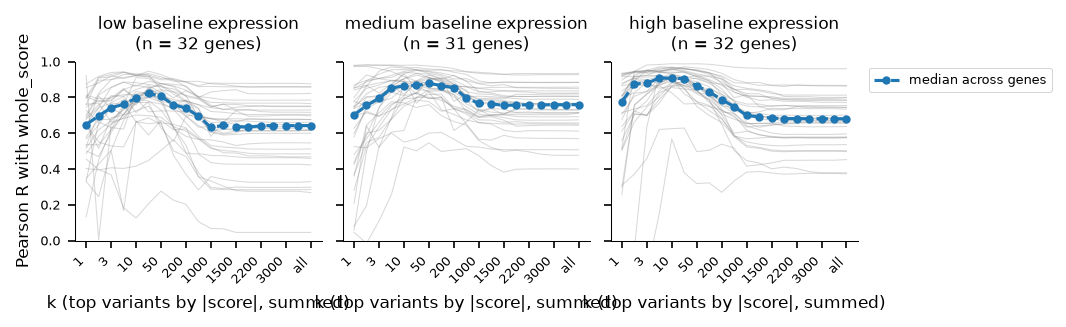

In [14]:
pivot_expr = pivot.join(ref_expr_by_gene, how="inner")
pivot_expr["expr_bin"] = expr_bin_by_gene.reindex(pivot_expr.index)

fig, axes = plt.subplots(1, 3, figsize=(18*cm, 5.5*cm), sharey=True)
for ax, bin_label in zip(axes, EXPR_BIN_LABELS):
    bin_pivot = pivot_expr.loc[pivot_expr["expr_bin"] == bin_label, ks_order]
    for _, row in bin_pivot.iterrows():
        ax.plot(x, row.to_numpy(), color="gray", alpha=0.3, lw=0.5)
    median_r = bin_pivot.median(axis=0)
    ax.plot(x, median_r.to_numpy(), color="tab:blue", ls="--", lw=1.5, marker="o", markersize=3, label="median across genes")
    ax.set_xticks(list(x)[::2])
    ax.set_xticklabels(ks_order[::2], rotation=45, ha="right")
    ax.set_ylim(0, 1)
    ax.set_xlabel("k (top variants by |score|, summed)")
    ax.set_title(f"{bin_label} baseline expression\n(n = {len(bin_pivot)} genes)", fontsize=8)
axes[0].set_ylabel("Pearson R with whole_score")
axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1))
fig.subplots_adjust(wspace=0.4)
fig.tight_layout()
fig.savefig(os.path.join(PDF_DIR, "correlation_vs_k_by_expression_bin.pdf"), bbox_inches="tight")